In [5]:
#This code block 
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('nasa_processed.csv') #read the processed dataset

#Select the relevant features that the model will learn from
FEATURES = ['Re', 'Rct', 'total_impedance', 'capacity_fade', 'cumulative_fade', 'ambient_temperature']
TARGET = 'fault_tier'

X = df[FEATURES]
y = df[TARGET]

#Split the data into training and testing sets, with 80% for training and 20% for testing.
#Startify keeps tier ratios equal in train and test sets -- important for imbalanced datasets like ours.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape) #shape is (number of samples, number of features)
print('--')
print(y_train.value_counts()) #Check the distribution of fault tiers in the training set = 80%
print('--')
print(y_test.value_counts()) #Check the distribution of fault tiers in the testing set = 20%


(1467, 6) (367, 6)
--
fault_tier
long     619
mid      558
short    290
Name: count, dtype: int64
--
fault_tier
long     155
mid      140
short     72
Name: count, dtype: int64


              precision    recall  f1-score   support

        long       0.97      0.96      0.97       155
         mid       0.93      0.91      0.92       140
       short       0.86      0.93      0.89        72

    accuracy                           0.93       367
   macro avg       0.92      0.93      0.93       367
weighted avg       0.94      0.93      0.93       367



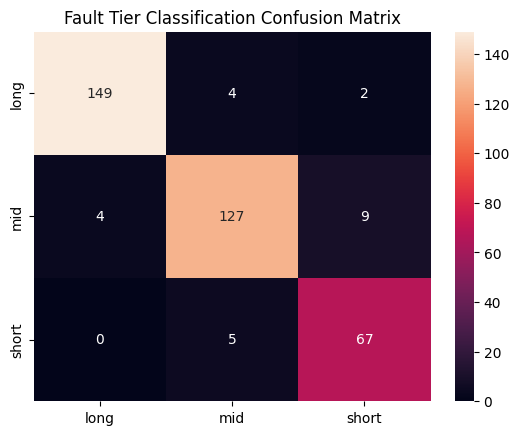

In [ ]:
#These libraries are for training the ML model and evaluating its performance.
from sklearn.ensemble import RandomForestClassifier #classification model, works well with non-linear data, can handle imbalanced datasets and tells us which features are most important for predictions.
from sklearn.preprocessing import LabelEncoder #converts categorical labels (like 'short', 'medium', 'long') into numerical format (0, 1, 2) for the model to understand

from sklearn.metrics import classification_report, confusion_matrix 
#Classification_report gives us precision, recall, f1-score for each class, and overall accuracy.
#Confusion_matrix shows us how many samples were correctly or incorrectly classified for each class, which helps us understand where the model is making mistakes.

import seaborn as sns 
#to visualize the confusion matrix as a HEATMAP => makes it easier to interpret the results and identify patterns in the model's performance across different fault tiers.

import matplotlib.pyplot as plt #to plot the heatmap and save it as an img file.

le = LabelEncoder() #convert labels to numerical values (short = 0, medium = 1, long = 2)

#transform the data relating to the target labels in both training and testing sets using the same encoder
y_train_encoded = le.fit_transform(y_train) 
y_test_encoded = le.transform(y_test) 

#Train the Random Forest Classifier on the training data and evaluate its performance on the testing data.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train_encoded)

y_pred = clf.predict(X_test) #clf.predict() gives us the predicted labels for the test set
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_)) 
#compare the actual y_test values to the y_pred values to see how the model is performing

'''Classification Report
precision = TP / (TP + FP) => of all the samples the model predicted as a certain class, how many were actually that class?
recall = TP / (TP + FN) => of all the samples that actually belong to a certain class, how many did the model correctly identify as that class?
f1-score = 2 * (precision * recall) / (precision + recall) => harmonic mean of precision and recall, gives us a single metric to evaluate the model's performance on each class.
''' 

#Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred) #x=predicted labels, y=actual labels
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Fault Tier Classification Confusion Matrix")
plt.savefig('confusion_matrix.png')
plt.show()



Feature Importance plot: analyze which features/sensors matter the most in detecting battery degradation

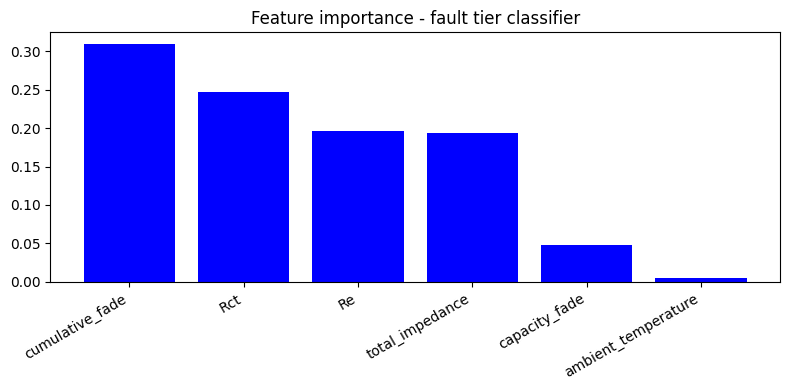

In [ ]:
import numpy as np #numerical operations: calculate mean, std, etc. for the SoH degradation plot

importances = clf.feature_importances_ #get the importance of each feature from the trained model
indices = np.argsort(importances)[::-1] #sort the feature importances in descending order

plt.figure(figsize=(8, 4))
plt.bar(range(len(FEATURES)), importances[indices], color='b', align='center')
plt.xticks(range(len(FEATURES)), [FEATURES[i] for i in indices], rotation=30, ha='right')
plt.title('Feature importance - fault tier classifier')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

#Cumulative fade (0.3), Rct(0.25), Re(0.2) and Total impedance(0.2) are the most important features for predicting fault tiers, according to the model.
#Why are these features low important (0.3?)


C:\Users\smumm\AppData\Local\Temp\ipykernel_14292\667998065.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  survival_df = df.groupby('battery_id').apply(lambda g: pd.Series({


Variance per feature:
mean_Re                  0.000527
mean_Rct                 0.001930
mean_total_impedance     0.003306
ambient_temp            39.655303
dtype: float64


<lifelines.CoxPHFitter: fitted with 33 total observations, 12 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 33
number of events observed = 21
   partial log-likelihood = -46.92
         time fit was run = 2026-03-21 13:06:23 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
mean_Re    9.47  12948.54     10.46          -11.03           29.97                0.00            1.04e+13
mean_Rct  20.04  5.04e+08      6.60            7.10           32.97             1215.21            2.09e+14

           cmp to    z      p  -log2(p)
covariate                              
mean_Re      0.00 0.91   0.37      1.45
mean_Rct     0.00 3.04 <0.005      8.70
---
Concordance = 0.70
Partial AIC = 97.84
log-likelihood ratio test = 12.52 on 2 df
-log2(p) of ll-ratio test = 9.03

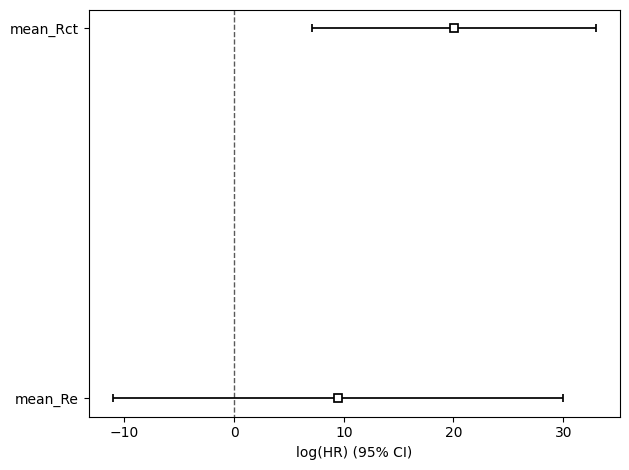

In [ ]:
from lifelines import CoxPHFitter #Cox Proportional Hazards model for survival analysis, helps us understand how different features affect the time until a certain event (like failure) occurs.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('nasa_processed.csv') #read the processed dataset

#Survival analysis needs:
#1. Duration = how many cycles the battery lasted until its failure
#2. Event = did it reach end-of-life (SoH < 80)

survival_df = df.groupby('battery_id').apply(lambda g: pd.Series({
    'duration': len(g),
    'event': int((g['SoH'] < 80).any()), #1 if the battery reached end-of-life, 0 otherwise
    'mean_Re': g['Re'].mean(),
    'mean_Rct': g['Rct'].mean(),
    'mean_total_impedance': g['total_impedance'].mean(),
    'ambient_temp': g['ambient_temperature'].iloc[0] #assuming ambient temp is constant for each battery
})).reset_index(drop=True) #group by battery_id to get one row per battery, calculate duration, event, and mean values for the features

# Check variance of each feature before fitting
print("Variance per feature:")
print(survival_df[['mean_Re','mean_Rct','mean_total_impedance','ambient_temp']].var())

# Drop ambient_temp (near-zero variance) and mean_total_impedance (collinear with Re+Rct)
survival_clean = survival_df.drop(columns=['ambient_temp', 'mean_total_impedance'])

cph = CoxPHFitter(penalizer=0.1)  # penalizer adds regularization — helps stability
cph.fit(survival_clean, duration_col='duration', event_col='event')
cph.print_summary()

cph.plot()
plt.tight_layout()
plt.savefig('cox_model_coefficients.png')
plt.show()

